<h1 style="text-align: center;">Feature Scaling Techniques</h1>
<h2 style="text-align: center;">Min-Max, Standard & Robust Scaling + Outlier Handling (Clipping, Winsorizing & Bounding)</h2>

In data science and machine learning, feature scaling is a critical preprocessing step that brings all numerical features to a similar
range. This helps distance-based algorithms (KNN, SVM, K-Means), gradient-based models (Neural Networks, regularized
Linear/Logistic Regression), and variance-based methods (PCA) perform better and converge faster.

To explain, we will use synthetic data designed to represent three common real-world situations:
- Normally distributed data
- Skewed data
- Data with extreme outliers

We will first examine the original distributions, then apply scaling techniques, and finally explore outlier-handling methods
(clipping, winsorizing, and bounding) that are frequently combined with scaling.
### Importing the Required Libraries

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
import seaborn as sns
from scipy.stats.mstats import winsorize

## 1. Generating Synthetic Data

In [25]:
#For reproducibility
np.random.seed(42)

# Normally distributed feature
feat_1 = np.random.normal(loc=60, scale=6, size=200)
# loc=60 → mean (μ) center of distribution (average value ≈ 60)
# scale=6 → standard deviation (σ) how spread out the data 

# Skewed feature (exponential distribution)
feat_2 = np.random.exponential(scale=60, size=200)
#scale=60 → mean of distribution controls how “stretched” it is

# Feature with extreme outliers
f = np.random.normal(loc=15, scale=3, size=195)
feat_3 = np.append(f, [f.max()+50, f.max()+100, f.max()+150, f.max()+200, f.max()+250])

df = pd.DataFrame(
    {
        'Normal': feat_1,
        'Skewed': feat_2,
        'With_Outliers': feat_3
    }
)

df.head()

,Normal,Skewed,With_Outliers
0,62.980285,125.916518,14.673720
1,59.170414,81.002055,16.205135
2,63.886131,71.644466,17.070432
3,69.138179,72.737253,13.796339
4,58.595080,26.729541,15.672277


We create a controlled dataset to illustrate different data challenges:
- Normal: Symmetric bell shaped distribution (ideal case)
- Skewed: Right skewed (common in real data like income or time to event)
- With_Outliers: Mostly normal but contaminated with five extreme values

**The reason for including the above three cases** is that the real datasets often combine these characteristics. By using the same
data throughout, we can clearly see how each technique responds to normality, skewness, and outliers.
## 2. Visualizing Original Distributions using Boxplots and KDE plots
Boxplots are one of the best tools to understand data distribution because they show:
- Median (middle line)
- Interquartile range (box)
- Whiskers (1.5 × IQR)
- Individual outliers (points beyond whiskers)

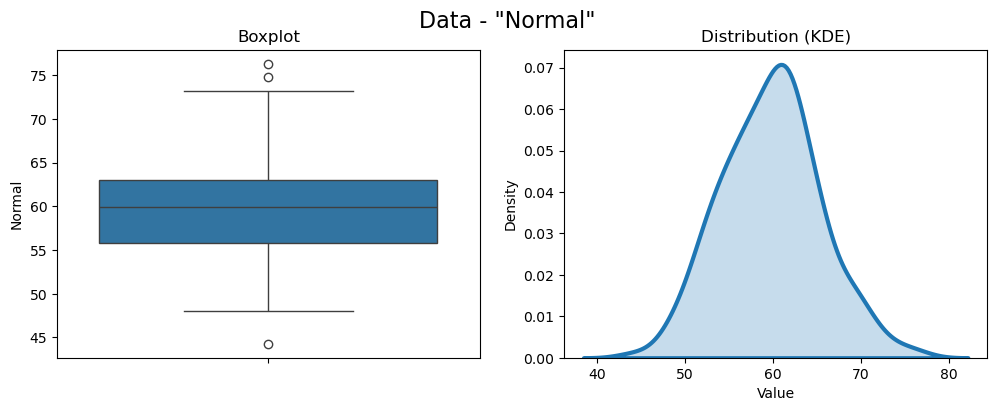

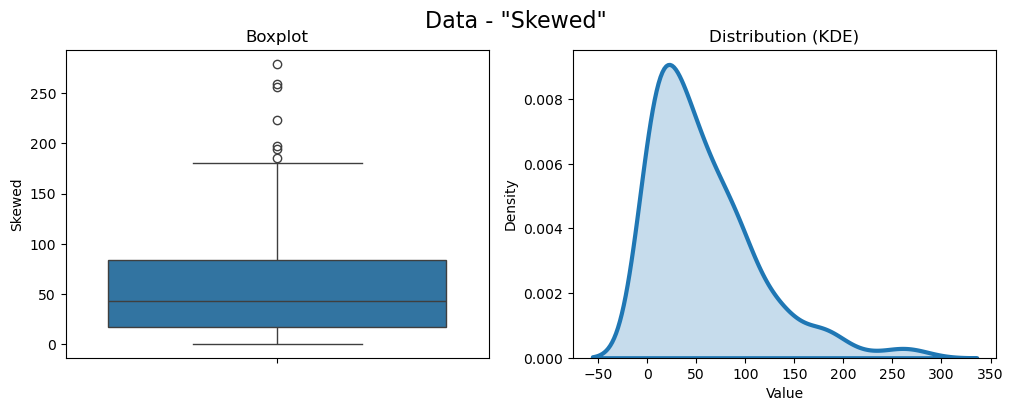

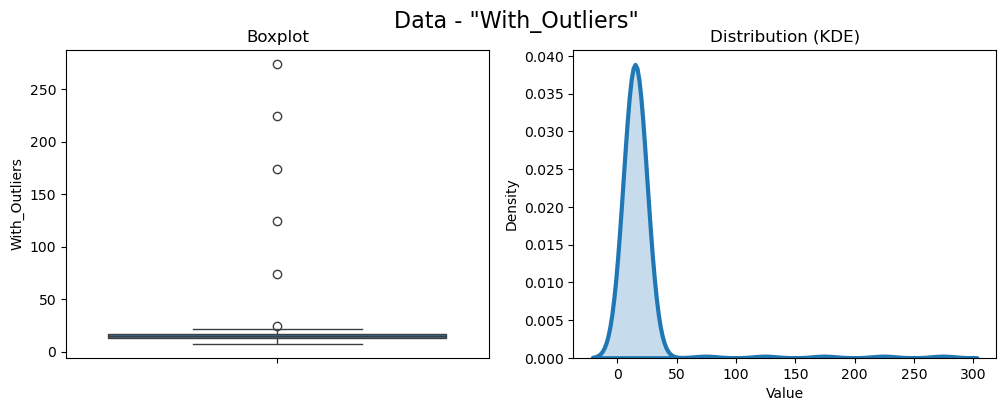

In [35]:
for col in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    fig.suptitle(f'Data - "{col}"',fontsize=16)
    
    sns.boxplot(y=df[col], ax=axes[0]).set_title('Boxplot')
    axes[0].set_ylabel(col)
    
    sns.kdeplot(df[col], fill=True, linewidth=3, ax=axes[1]).set_title('Distribution (KDE)')
    axes[1].set_xlabel('Value')
    axes[1].set_ylabel('Density')
    
    plt.show()

## 3. Applying Scalers

In [5]:
# Initializing the scalers
minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

# Fit and Transform
minmax_scal = minmax_scaler.fit_transform(df)
standard_scal = standard_scaler.fit_transform(df)
robust_scal = robust_scaler.fit_transform(df)
print(f"MinMaxScaler output: {minmax_scal[:2]} \n")
print(f"StandardScaler: {standard_scal[:2]} \n")
print(f"RobustScaler: {robust_scal[:2]} \n")

MinMaxScaler output: [[0.58361597 0.44934638 0.02658395]
 [0.46470424 0.28822778 0.03232709]] 

StandardScaler: [[ 0.57876651  1.25327389 -0.15071353]
 [-0.10498128  0.4244209  -0.09491881]] 

RobustScaler: [[ 0.41535181  1.24126977 -0.04738283]
 [-0.11117299  0.56668602  0.31205043]] 



As you can see, the transformed dataset produced by the scaler transformer is in array format. We need to convert it into a
DataFrame so that the visualization step will be easier.

In [6]:
# put the scaled dataset in a dataframe
df_minmax = pd.DataFrame(minmax_scal,columns=df.columns)
df_standard = pd.DataFrame(standard_scal, columns=df.columns)
df_robust = pd.DataFrame(robust_scal, columns=df.columns)

## 4. Visualizing the Scaled Distributions (Boxplot side by side)
### 4.1. Original Distributions

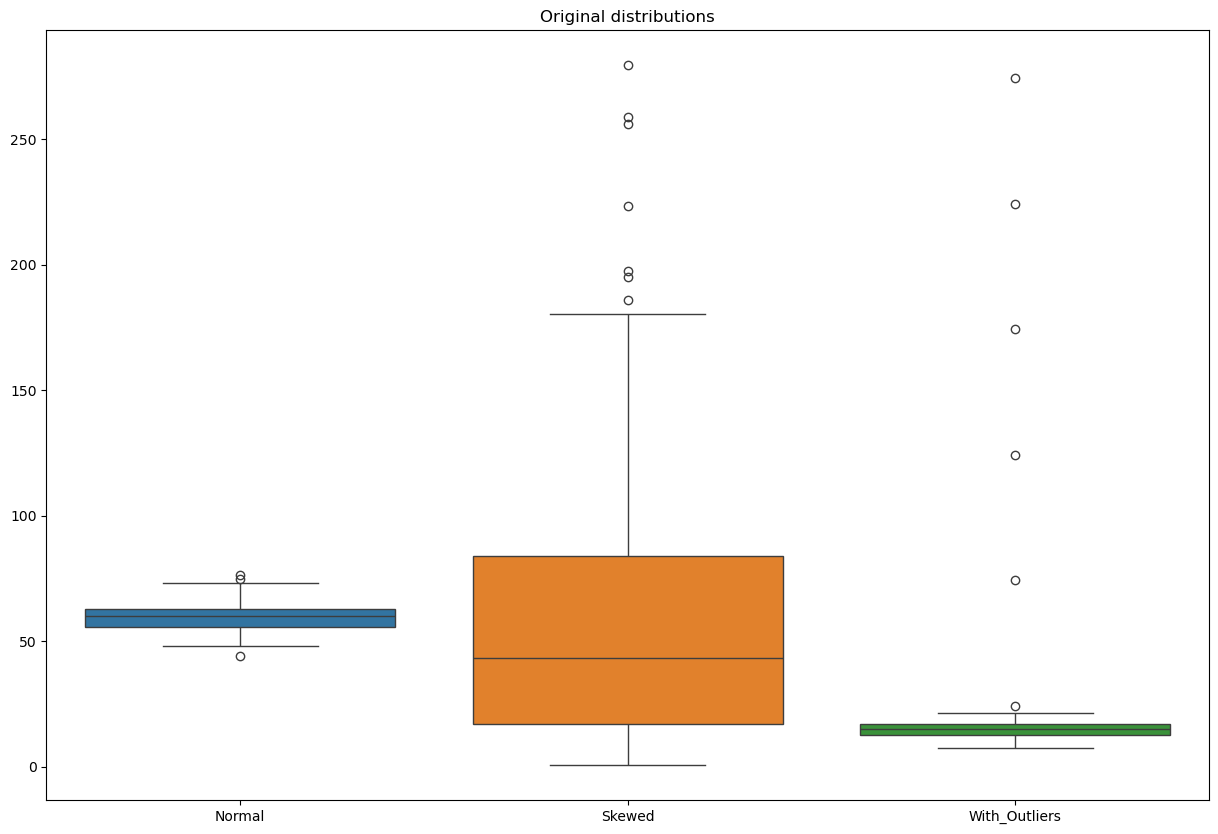

In [7]:
plt.figure(figsize=(15, 10))
plt.title("Original distributions")
sns.boxplot(df);

### 4.2. Min-Max scaling

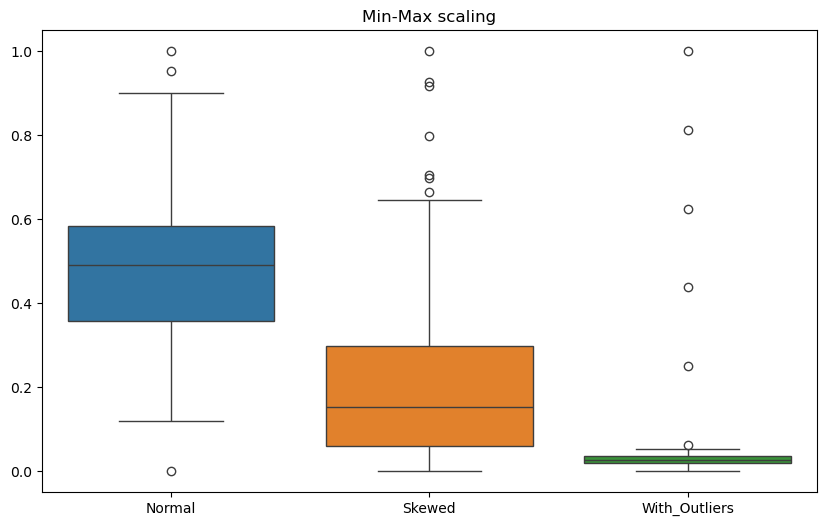

In [8]:
plt.figure(figsize=(10, 6))
plt.title("Min-Max scaling")
sns.boxplot(df_minmax); 

### 4.3. Standard scaling

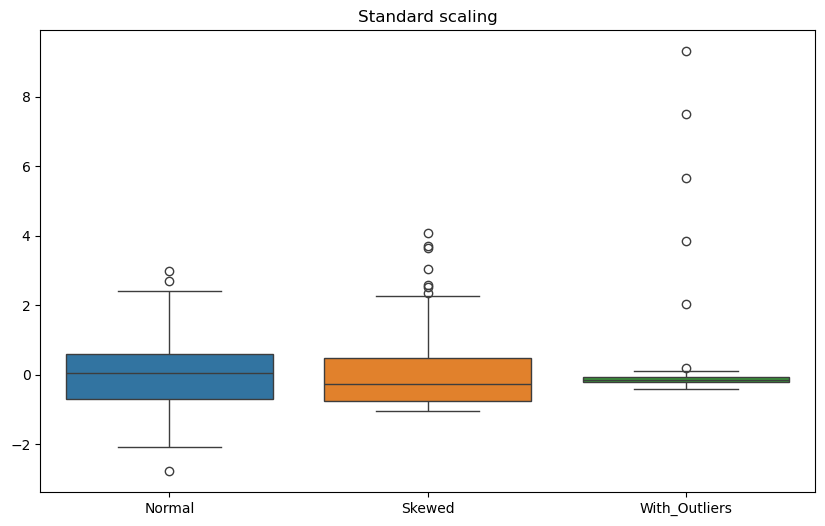

In [9]:

plt.figure(figsize=(10, 6))
plt.title("Standard scaling")
sns.boxplot(df_standard);

## 4.4. Robust Scaling

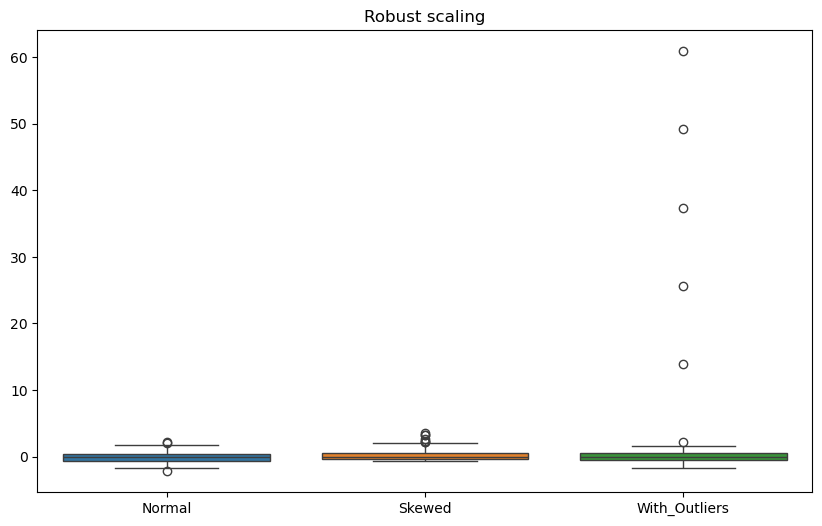

In [11]:
plt.figure(figsize=(10, 6))
plt.title("Robust scaling")
sns.boxplot(df_robust, showfliers = True);

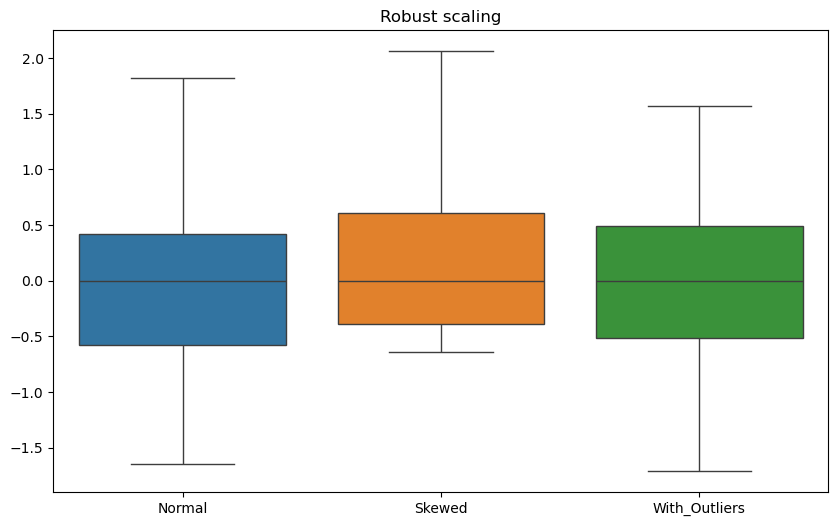

In [47]:
plt.figure(figsize=(10, 6))
plt.title("Robust scaling")
sns.boxplot(df_robust, showfliers = False);

- When showfliers=True , you can see that the original extreme values remain far out (RobustScaler does NOT clip or remove outliers)
- When showfliers=False , the main body of data looks beautifully centered at 0 with IQR = 1.

**Robust scaling** helps keep most of the data well behaved while still keeping outliers as they are. This makes it a safe default choice
for messy, real-world datasets.

It works by using the median (instead of the mean) and the interquartile range (the middle 50% of the data). Because of this,
extreme values don’t distort the scale of the majority of the data.

**MinMaxScaler** Scales to [0, 1]. Outliers compress the normal data into a very narrow range.

**StandardScaler** Centers at mean = 0, std = 1. Outliers strongly influence mean and std. It distorts the scale of normal points.

## Outlier Handling Techniques (Clipping, Winsorizing & Bounding)
Before or after scaling, we often need to manage outliers explicitly. Here are three common, practical methods using the exact same
data.
### 1. Clipping (Hard Bounds)
   
Clipping replaces values outside fixed thresholds with the threshold values. It is simple and fast but requires domain knowledge for
choosing bounds.

In [40]:
df_clipped = df.copy()
df_clipped['With_Outliers'] = np.clip(df['With_Outliers'], 0, 200)

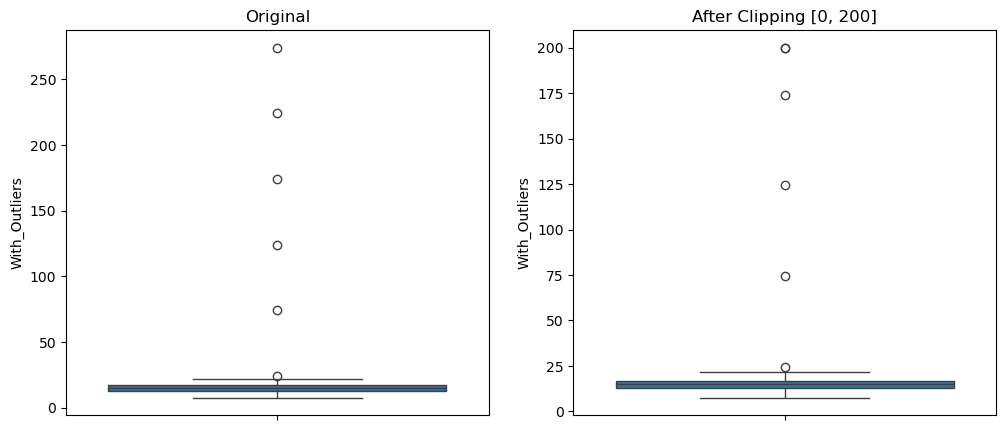

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
sns.boxplot(df['With_Outliers'], ax=axes[0]).set_title("Original")

sns.boxplot(df_clipped['With_Outliers'], ax=axes[1]).set_title("After Clipping [0, 200]")

plt.show()

## 2. Bounding (Domain-Based Limits)
Bounding applies logical or business constraints (e.g., age cannot exceed 120, price cannot be negative). It is very common in
production systems

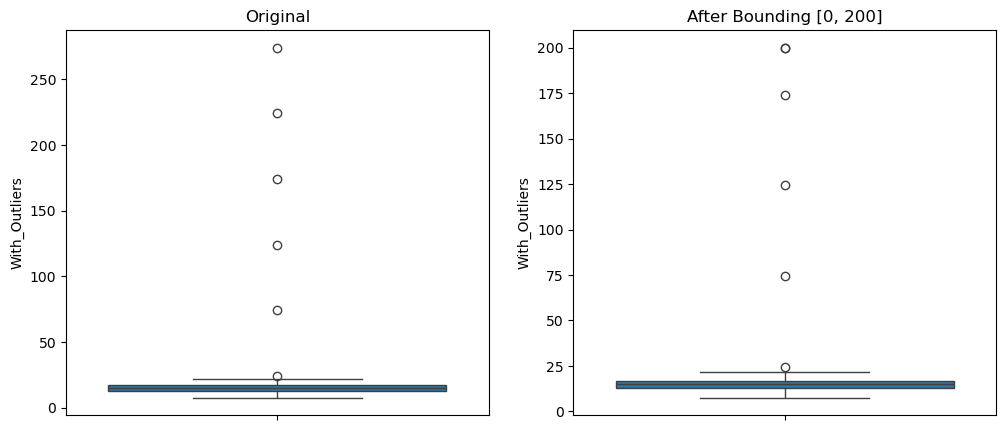

In [43]:
df_bounded = df.copy()
df_bounded['With_Outliers'] = np.clip(df['With_Outliers'], 0, 200) # domain-based upper limit

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1); 
sns.boxplot(df['With_Outliers']).set_title("Original")

plt.subplot(1, 2, 2); 
sns.boxplot(df_bounded['With_Outliers']).set_title("After Bounding [0, 200]")

plt.show()

## 2. Winsorizing (Percentile-Based Capping)
Winsorizing replaces extreme values with the values at chosen percentiles (e.g., 5th and 95th). It is data-driven and keeps all
observations (no data loss)

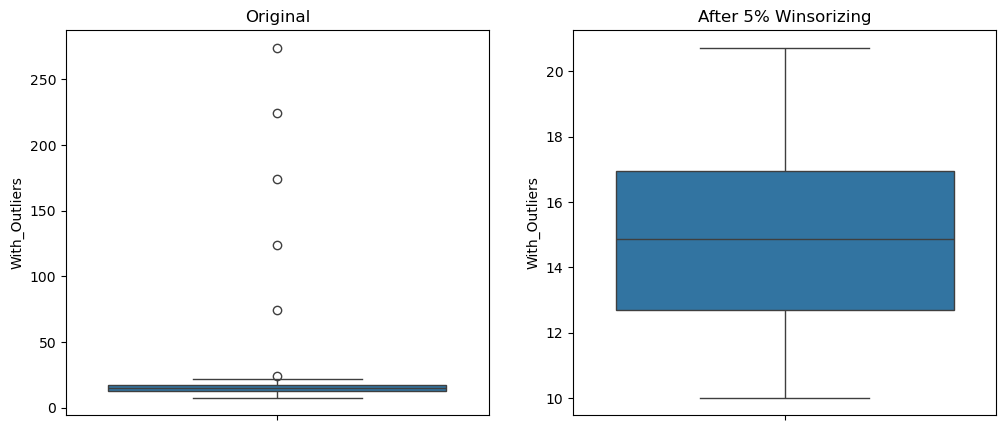

In [46]:
from scipy.stats.mstats import winsorize

df_winsor = df.copy()

df_winsor['With_Outliers'] = winsorize(df['With_Outliers'], limits=[0.05, 0.05])

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1); 
sns.boxplot(df['With_Outliers']).set_title("Original")

plt.subplot(1, 2, 2); 
sns.boxplot(df_winsor['With_Outliers']).set_title("After 5% Winsorizing")

plt.show()